In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)
library(decontX)
library(ggsci)
library(patchwork)   # env:seurat_v5

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
packageVersion("Seurat")
packageVersion("dplyr")
packageVersion("ggplot2")
packageVersion("tidyr")
packageVersion("ggsci")
packageVersion("decontX")
packageVersion("patchwork")
packageVersion("igraph")

[1] ‘5.1.0’

[1] ‘1.1.4’

[1] ‘3.5.1’

[1] ‘1.3.1’

[1] ‘3.2.0’

[1] ‘1.4.0’

[1] ‘1.2.0’

[1] ‘2.1.4’

# 1. 读取数据

In [3]:
# 读取 Part 3 跑完初步 Harmony 的数据
sc <- readRDS('./Results/Test_Tilapia_harmony.rds')

In [4]:
sc_filtered <- sc
sc_filtered

An object of class Seurat 
15994 features across 1842 samples within 1 assay 
Active assay: RNA (15994 features, 2000 variable features)
 5 layers present: counts.1, counts.2, data.1, data.2, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

In [5]:
# 在 Seurat v5 中，提取原始 counts 前需要先将拆分的批次图层合并
sc_filtered <- JoinLayers(sc_filtered)

# 2. 运行 decontX 评估环境 RNA 污染 (Contamination)

In [6]:
# 提取 counts 矩阵喂给 decontX 算法
counts <- sc_filtered@assays$RNA@layers$counts
decontX_res <- decontX(counts)

--------------------------------------------------

Starting DecontX

--------------------------------------------------

Mon Apr 20 18:14:44 2026 .. Analyzing all cells

Mon Apr 20 18:14:44 2026 .... Generating UMAP and estimating cell types

Mon Apr 20 18:14:53 2026 .... Estimating contamination

Mon Apr 20 18:14:53 2026 ...... Completed iteration: 10 | converge: 0.01907

Mon Apr 20 18:14:53 2026 ...... Completed iteration: 20 | converge: 0.007667

Mon Apr 20 18:14:54 2026 ...... Completed iteration: 30 | converge: 0.003813

Mon Apr 20 18:14:54 2026 ...... Completed iteration: 40 | converge: 0.002403

Mon Apr 20 18:14:55 2026 ...... Completed iteration: 50 | converge: 0.001775

Mon Apr 20 18:14:55 2026 ...... Completed iteration: 60 | converge: 0.001568

Mon Apr 20 18:14:55 2026 ...... Completed iteration: 70 | converge: 0.001339

Mon Apr 20 18:14:56 2026 ...... Completed iteration: 80 | converge: 0.001096

Mon Apr 20 18:14:56 2026 ...... Completed iteration: 90 | converge: 0.001029


In [7]:
# 将 decontX 估计的细胞污染比例添加到 Seurat 对象的元数据中
sc_filtered$Contamination <- decontX_res$contamination

# 3. 污染比例的可视化与评估

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


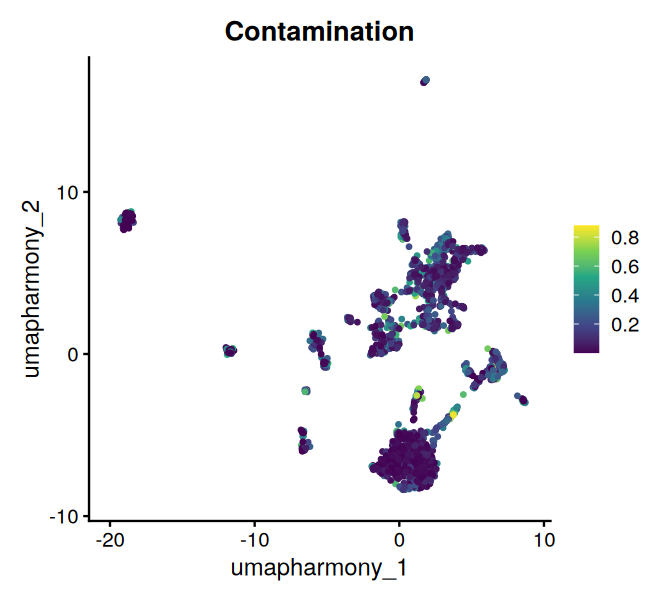

In [8]:
# 在 UMAP 降维图上可视化细胞的污染比例 (连续变量，使用 viridis 渐变色)
options(repr.plot.width = 5.5, repr.plot.height = 5)
FeaturePlot(sc_filtered, features = 'Contamination', reduction = 'umap.harmony') + 
  scale_color_viridis_c()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


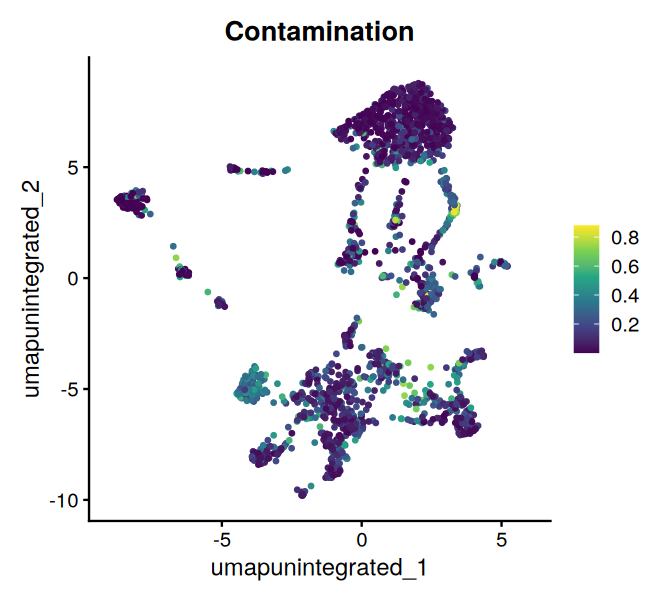

In [9]:
options(repr.plot.width = 5.5, repr.plot.height = 5)
FeaturePlot(sc_filtered, features = 'Contamination') + 
  scale_color_viridis_c()

In [10]:
# 查看污染比例的总体分位数分布
quantile(decontX_res$contamination, probs = c(0.01,0.5,0.75,0.9))
sc_filtered

1%          50%          75%          90% 
0.0005432291 0.0923947040 0.2477257056 0.4127262740

An object of class Seurat 
15994 features across 1842 samples within 1 assay 
Active assay: RNA (15994 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

In [11]:
# 计算动态阈值参考：中位数 + 3 倍绝对中位差 (MAD)
median(sc_filtered$Contamination) + 3*mad(sc_filtered$Contamination)

[1] 0.4522549

In [12]:
# 定义各样本专属颜色
sample_cols <- c('T1' = '#CC88B0', 'T2' = '#998DB7')

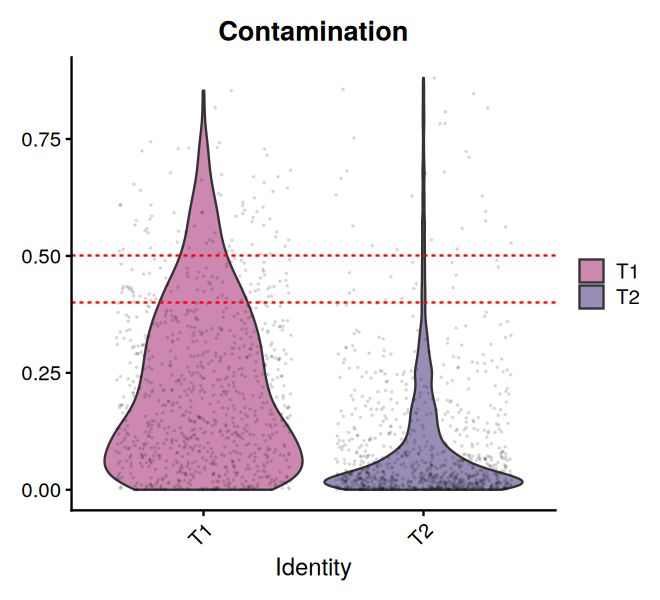

In [13]:
# 分 Sample 可视化污染比例的分布情况 (添加红色虚线作为备选阈值参考)
options(repr.plot.width = 5.5, repr.plot.height = 5)
VlnPlot(sc_filtered, features = "Contamination", group.by = "sample", cols = sample_cols, pt.size = 0.01, alpha = 0.1) + 
  geom_hline(yintercept = c(0.4, 0.5), linetype = "dashed", color = "red")

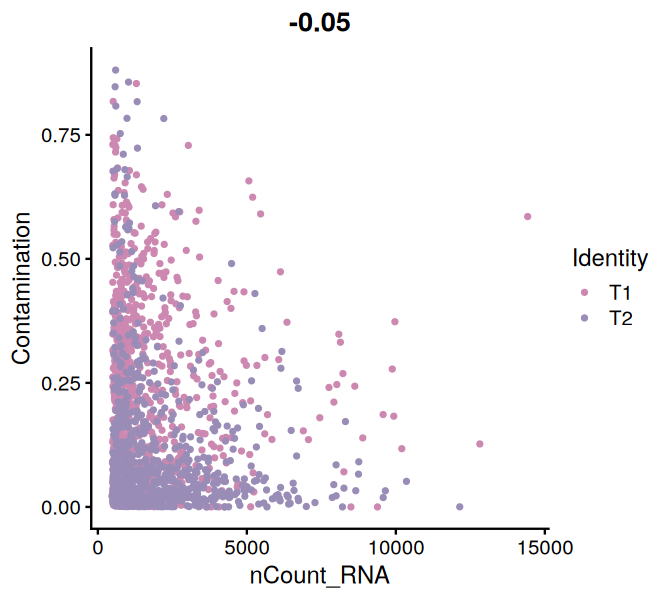

In [14]:
# 观察测序深度与污染比例的关系
FeatureScatter(sc_filtered, feature1 = "nCount_RNA", feature2 = "Contamination", group.by = 'sample', cols = sample_cols)

# 4. 动态阈值过滤评估

In [15]:
# 函数1：评估全局不同 Contamination 阈值对保留细胞数的影响
ContaminationQC <- function(seurat_obj, thresholds = c(0.3, 0.4, 0.5)) {
  total_cells <- ncol(seurat_obj)
  results <- data.frame(threshold = numeric(), retained_cells = integer(), retained_percent = numeric())
  
  for (threshold in thresholds) {
    filtered <- seurat_obj[, seurat_obj$Contamination < threshold]
    retained <- ncol(filtered)
    percent_retained <- round((retained / total_cells) * 100, 2)
    results <- rbind(results, data.frame(threshold = threshold, retained_cells = retained, retained_percent = percent_retained))
  }
  return(results)
}
ContaminationQC(sc_filtered)

threshold,retained_cells,retained_percent
<dbl>,<dbl>,<dbl>
0.3,1489,80.84
0.4,1642,89.14
0.5,1740,94.46


In [16]:
# 函数2：分样本评估不同阈值的影响
ContaminationQC_bySample <- function(seurat_obj, thresholds = c(0.3, 0.25, 0.2)) {
  if (!"Contamination" %in% names(seurat_obj@meta.data)) stop("缺少Contamination信息")
  
  sample_column <- ifelse("Sample" %in% names(seurat_obj@meta.data), "Sample", 
                          ifelse("sample" %in% names(seurat_obj@meta.data), "sample", stop("缺少Sample/sample信息")))
  
  samples <- unique(seurat_obj@meta.data[[sample_column]])
  results <- data.frame(sample = character(), threshold = numeric(), total_cells = integer(), 
                        retained_cells = integer(), retained_percent = numeric(), stringsAsFactors = FALSE)
  
  for (s in samples) {
    sample_cells <- seurat_obj[, seurat_obj@meta.data[[sample_column]] == s]
    total_sample_cells <- ncol(sample_cells)
    
    for (threshold in thresholds) {
      filtered <- sample_cells[, sample_cells$Contamination < threshold]
      retained <- ncol(filtered)
      percent_retained <- round((retained / total_sample_cells) * 100, 2)
      results <- rbind(results, data.frame(sample = s, threshold = threshold, total_cells = total_sample_cells, 
                                           retained_cells = retained, retained_percent = percent_retained, stringsAsFactors = FALSE))
    }
  }
  return(results)
}

In [17]:
qc_results <- ContaminationQC_bySample(sc_filtered)
qc_results

sample,threshold,total_cells,retained_cells,retained_percent
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
T1,0.30,920,636,69.13
T1,0.25,920,564,61.30
T1,0.20,920,480,52.17
T2,0.30,922,853,92.52
T2,0.25,922,818,88.72
T2,0.20,922,785,85.14


In [18]:
# 保存带有 Contamination 评分的中间状态数据
saveRDS(sc_filtered,'./Results/Test_Tilapia_Filtered.rds')
sc_filtered <- readRDS('./Results/Test_Tilapia_Filtered.rds')

# 5. 执行严格过滤并重新进行 Harmony 整合

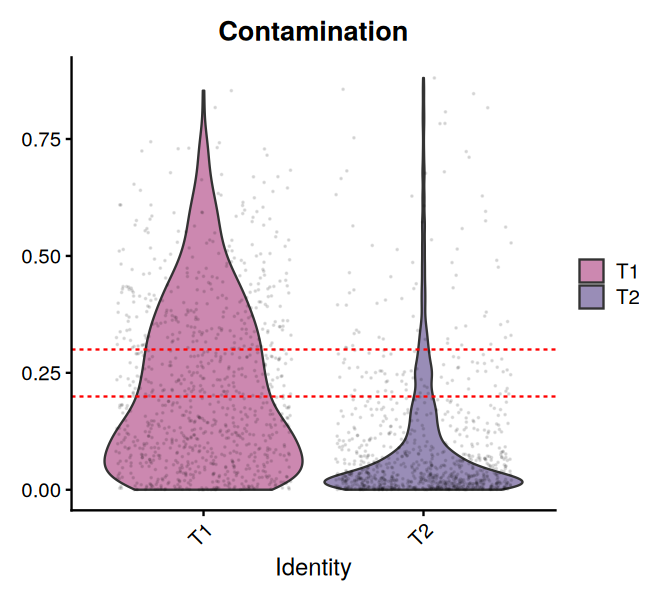

In [19]:
options(repr.plot.width = 5.5, repr.plot.height = 5)
VlnPlot(sc_filtered, features = "Contamination", group.by = "sample", cols = sample_cols, pt.size = 0.01, alpha = 0.1) + 
  geom_hline(yintercept = c(0.2, 0.3), linetype = "dashed", color = "red")

In [20]:
# 过滤低污染细胞 (Contamination < 0.3) 并二次确认去除潜在双细胞 (nFeature_RNA < 4000)
sc_lc <- sc_filtered[, sc_filtered$Contamination < 0.3]
sc_lc <- sc_lc[, sc_lc$nFeature_RNA < 4000]
sc_lc

An object of class Seurat 
15994 features across 1489 samples within 1 assay 
Active assay: RNA (15994 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

In [21]:
# 重新拆分图层
sc_lc[['RNA']] <- split(sc_lc[['RNA']], f = sc_lc$orig.ident)

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.



In [22]:
# 执行 Harmony 整合
sc_lc <- IntegrateLayers(
  object = sc_lc, method = HarmonyIntegration,
  orig.reduction = "pca", new.reduction = "harmony",
  verbose = FALSE
)

Warning message:
“HarmonyMatrix is deprecated and will be removed in the future from the API in the future”
Warning message:
“Warning: The parameters do_pca and npcs are deprecated. They will be ignored for this function call and please remove parameters do_pca and npcs and pass to harmony cell_embeddings directly.
This warning is displayed once per session.”
Warning message:
“Warning: The parameter tau is deprecated. It will be ignored for this function call and please remove parameter tau in future function calls. Advanced users can set value of parameter tau by using parameter .options and function harmony_options().
This warning is displayed once per session.”
Warning message:
“Warning: The parameter block.size is deprecated. It will be ignored for this function call and please remove parameter block.size in future function calls. Advanced users can set value of parameter block.size by using parameter .options and function harmony_options().
This warning is displayed once per sessi

In [23]:
# 重新降维与聚类
sc_lc <- sc_lc %>%
  FindNeighbors(reduction = "harmony", dims = 1:30, verbose = F) %>%
  FindClusters(resolution = c(0.1, 0.2, 0.4, 0.8), cluster.name = c('harmony_clusters_0.1', 'harmony_clusters_0.2', 'harmony_clusters_0.4', 'harmony_clusters_0.8'), verbose = F) %>%
  RunUMAP(reduction = "harmony", dims = 1:30, reduction.name = 'umap.harmony', verbose = FALSE)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


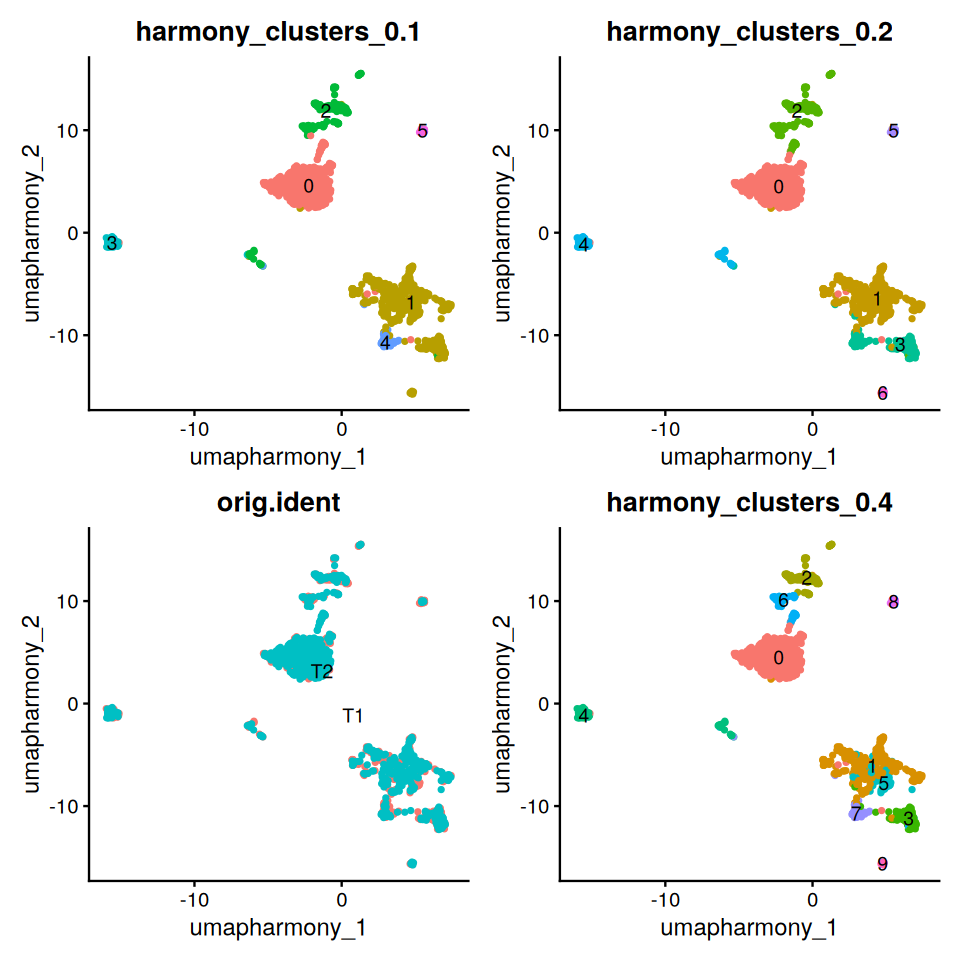

In [24]:
# 可视化重新整合后的结果
options(repr.plot.width = 8, repr.plot.height = 8)
plot1 <- DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.1") + NoLegend()
plot2 <- DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.2") + NoLegend()
plot4 <- DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by = "harmony_clusters_0.4") + NoLegend()
plot3 <- DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by = "orig.ident") + NoLegend()
plot1 + plot2 + plot3 + plot4 + plot_layout(nrow = 2)

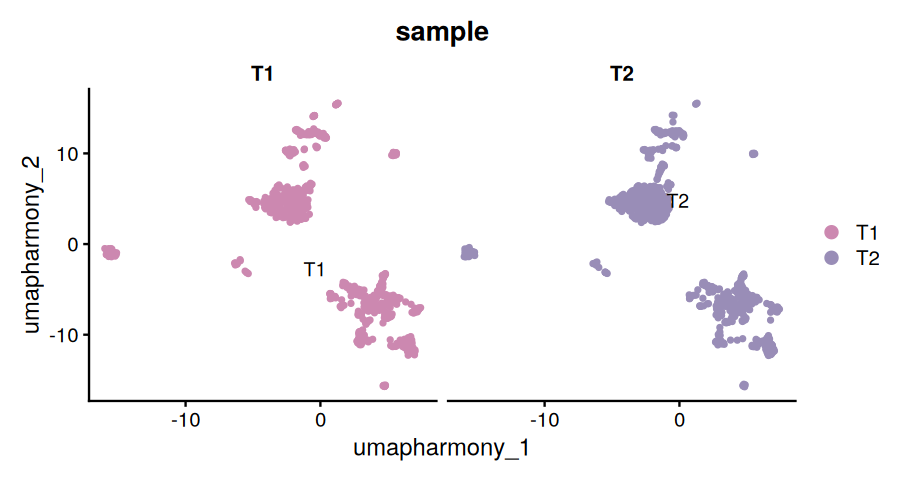

In [26]:
options(repr.plot.width = 7.5, repr.plot.height = 4)
DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by = c("sample"), repel = T, split.by = "orig.ident", cols = sample_cols)

In [27]:
# 整合完成后重新合并图层
sc_lc <- JoinLayers(sc_lc)
saveRDS(sc_lc,'./Results/Test_Tilapia_Low_Contamination.rds')

# 6. 寻找 Marker 基因并进行细胞类型注释

In [28]:
sc_lc

An object of class Seurat 
15994 features across 1489 samples within 1 assay 
Active assay: RNA (15994 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

In [29]:
# 设置目标聚类分辨率为 0.2,具体以聚类分簇情况而定
Idents(sc_lc) = "harmony_clusters_0.2"

In [30]:
# 寻找所有聚类的差异表达基因 (仅保留正向表达且 logfc > 0.5)
mak <- FindAllMarkers(sc_lc, only.pos = TRUE, logfc.threshold = 0.5)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6



In [31]:
# 导入罗非鱼至斑马鱼的同源基因映射字典
tilapia_id_name <- read.delim("./Results/oni2zebra.txt", h=T, sep="\t")
colnames(tilapia_id_name) <- c("gene_ID", "gene_name")

In [32]:
# 对差异基因结果进行过滤、合并基因名并输出
mak <- mak %>% 
  filter(p_val_adj < 0.01 & pct.1 > 0.1) %>% 
  group_by(gene) %>% 
  left_join(tilapia_id_name, by = c("gene"="gene_ID"), multiple = "first") %>% 
  ungroup()

In [33]:
head(mak)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,gene_name
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>
9.745366e-180,3.905595,0.862,0.183,1.558674e-175,0,ENSONIG00000002954,SNAP25
5.655717e-175,3.301327,0.923,0.361,9.045754e-171,0,ENSONIG00000005047,qkia
3.145121e-170,3.303112,0.884,0.218,5.030307e-166,0,ENSONIG00000041800,ZIC1
3.473164e-158,4.119123,0.767,0.117,5.554978e-154,0,ENSONIG00000034012,cbln12
3.088357e-154,3.310380,0.860,0.304,4.939518e-150,0,ENSONIG00000007270,PTPRF
1.479866e-151,2.845062,0.884,0.318,2.366897e-147,0,ENSONIG00000011044,nrxn3b


In [34]:
write.table(mak, './Results/Test_Tilapia_harmony_0.2_Mak.tsv', sep = '\t', row.names = F)

# 7. 经典 Marker 基因可视化 (FeaturePlot & DotPlot)

In [42]:
# 定义目标绘制基因字典
dotPlotGene <- c(
  "ENSONIG00000014579", "ENSONIG00000000724", "ENSONIG00000002184", "ENSONIG00000036657",
  "ENSONIG00000010119", "ENSONIG00000013056", "ENSONIG00000003001", "ENSONIG00000002954",
  "ENSONIG00000009549", "ENSONIG00000013097"
)
gene_name <- c("slc1a2","GFAP","alas2","MPZ","ptprc","cd47a","gad2","snap25",'RBFOX3',"pvalb7")
names(dotPlotGene) <- gene_name

In [43]:
# 批量绘制深度自定义的 FeaturePlot
cols_function <- colorRampPalette(colors = c("#e6e6e6", viridis::viridis(option = "C", n = 10, begin = 0.87, end = 0)))(100)
plot.list <- lapply(1:(length(dotPlotGene)), function(i) {
  p <- FeaturePlot(sc_lc, raster = TRUE, features = dotPlotGene[i], pt.size = 3, reduction = "umap.harmony") + 
    ggtitle(names(dotPlotGene[i])) + 
    scale_color_gradientn(colours = cols_function) + 
    guides(color = guide_colourbar(ticks = FALSE, barwidth = .6, frame.colour = "black", frame.linewidth = .5)) +
    theme(axis.line = element_blank(), axis.ticks = element_blank(), axis.text = element_blank(), 
          axis.title = element_blank(), plot.title = element_text(hjust = .5, face = "italic", color = "black"),
          legend.box = "vertical", legend.key.height = unit(0.04, "npc"))
  return(p) 
})

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is

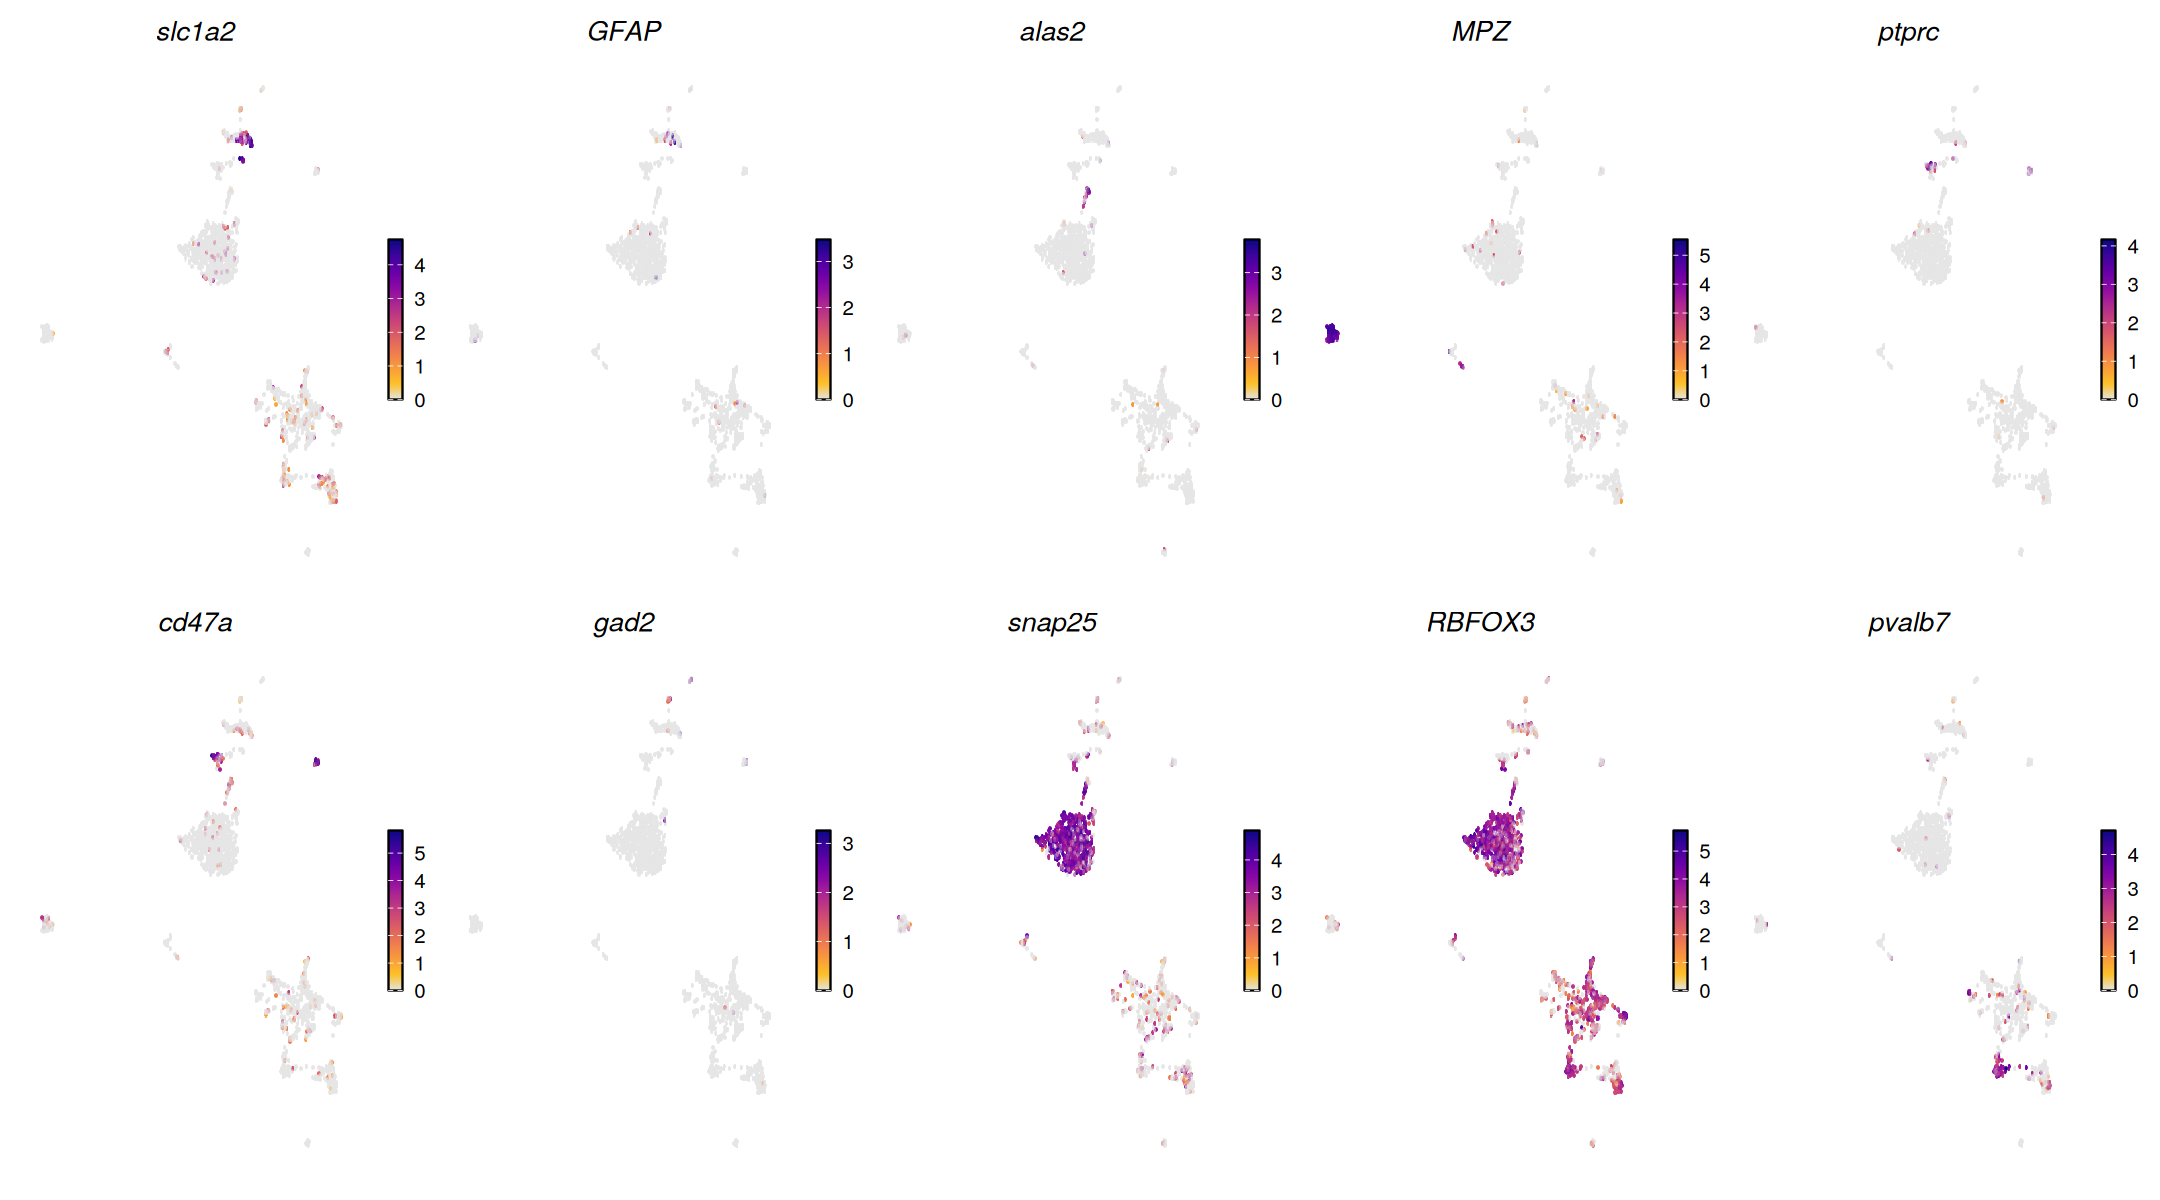

In [44]:
options(repr.plot.width = 18, repr.plot.height = 10)
p.featurePlot <- patchwork::wrap_plots(plotlist = plot.list, ncol = 5)
p.featurePlot

# 8. 细分亚群与大类

In [45]:
options(repr.plot.width = 4.5, repr.plot.height = 5)
P_0.2 <- DimPlot(sc_lc, reduction = "umap.harmony", label = T, group.by ="harmony_clusters_0.2")

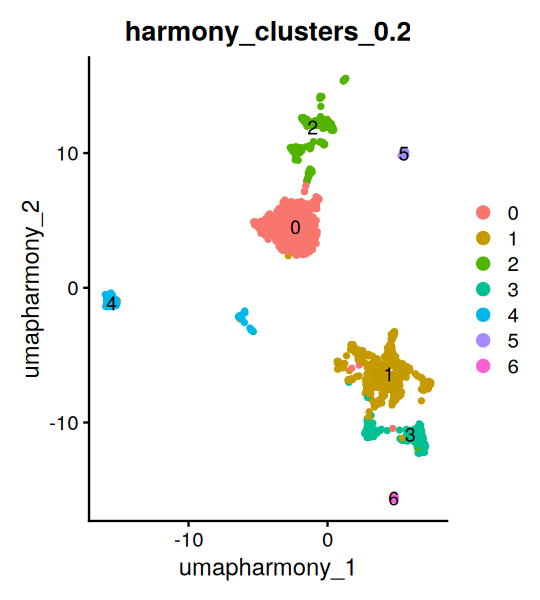

In [46]:
P_0.2

In [51]:
# 基因list
dotPlotGene <- c("ENSONIG00000014579", # slc1a2
                 "ENSONIG00000000724", # GFAP
                 "ENSONIG00000002184", # alas2
                 "ENSONIG00000036657", # MPZ
                 "ENSONIG00000013788", # mbpa
#                 "ENSONIG00000009878", # sox5
                 "ENSONIG00000037001", # SOX10
                 "ENSONIG00000008139", # NKX2-2
                 "ENSONIG00000010119", # ptprc
                 "ENSONIG00000013056", # cd47a
                 "ENSONIG00000006415", # gad2
                 "ENSONIG00000008762", # gad1
                 "ENSONIG00000004254", # FAT2
                 "ENSONIG00000019373", # SLC17A7
                 "ENSONIG00000002954", # snap25
                 "ENSONIG00000009549",  # RBFOX3
                 "ENSONIG00000008933",  # TBR1
                 "ENSONIG00000013097" # pvalb7
                
                )

In [68]:
# gene id 和 gene name对应信息
dot_plot_genes <- c(
    PTPRC = "ENSONIG00000010119",
    cd47a = "ENSONIG00000013056",
    MPZ = "ENSONIG00000036657",
    mbpa = "ENSONIG00000013788",
    pvalb7 = "ENSONIG00000013097",
    slc1a2 = "ENSONIG00000014579",
    gad2 = "ENSONIG00000006415",
    gad1 = "ENSONIG00000008762",
    FAT2 = "ENSONIG00000004254",
    SLC17A7 = "ENSONIG00000019373",
    RBFOX3 = "ENSONIG00000009549",
    snap25 = "ENSONIG00000002954"
)
length(dot_plot_genes)

[1] 12

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


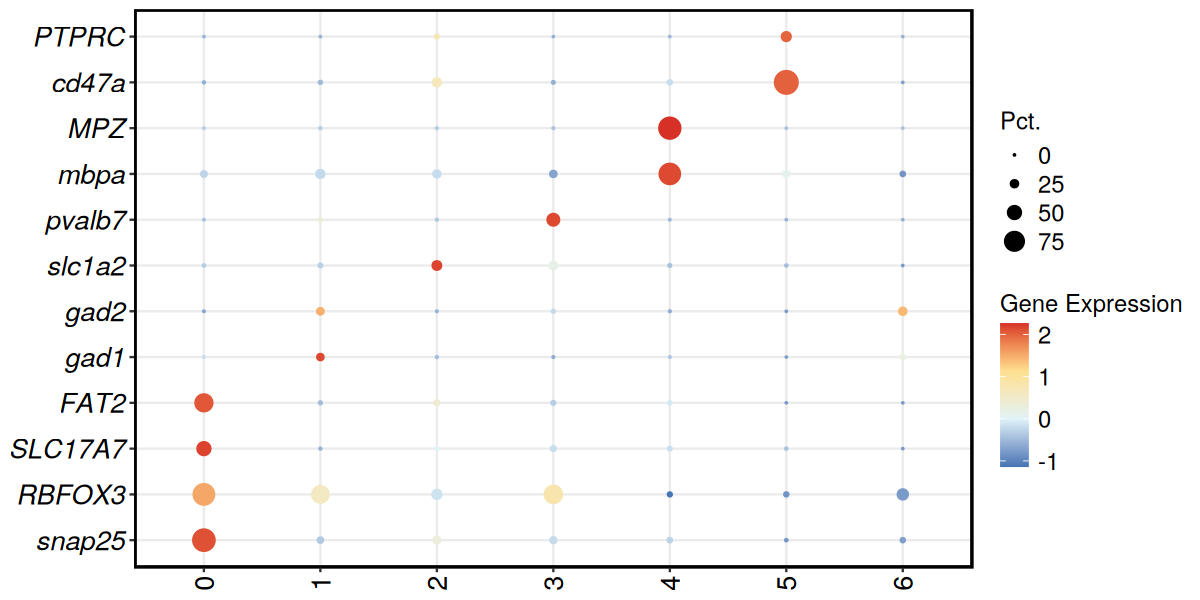

In [69]:
options(repr.plot.width = 10, repr.plot.height = 5)
plot <- DotPlot(sc_lc,features = rev(unname(dot_plot_genes)),group.by = 'harmony_clusters_0.2') +
    scale_x_discrete(label = rev(names(dot_plot_genes)) ) +
    coord_flip() +
    theme_bw() +
    theme(#panel.grid = element_blank(),
          legend.title = element_text(size = 14),
          legend.text = element_text(size = 14),
          panel.border = element_rect(color = "black", size = 1),
          axis.text.x = element_text(angle=90,hjust = 1,vjust=0.5,size=16,colour = 'black'),
          axis.text.y = element_text(size=16,colour = 'black', face = "italic")) +
    scale_color_gradientn(values = seq(0,1,0.2),colours = c('#4575B4','#E0F3F8','#FEE090','#D73027'))+
    labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3)) +
    guides(size = guide_legend(title = "Pct."),color = guide_colorbar(title = "Gene Expression"))
plot

In [70]:
# 细分亚群字典 (celltype)
group_celltype_dict <- c(
  "0" = "EN",  # 兴奋性神经元
  "1" = "IN1", # 抑制性神经元
  "2" = "AST", # 星形胶质细胞
  "3" = "IN2", # 抑制性神经元
  "4" = "OLG", # 少突胶质细胞
  "5" = "B",  # B细胞
  "6" = "NA"  # 未知
)
sc_lc[['celltype']] = unname(group_celltype_dict[sc_lc@meta.data$harmony_clusters_0.2])

In [71]:
head(sc_lc,3)

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,unintegrated_clusters_0.1,unintegrated_clusters_0.2,unintegrated_clusters_0.4,unintegrated_clusters_0.8,seurat_clusters,harmony_clusters_0.1,harmony_clusters_0.2,harmony_clusters_0.4,harmony_clusters_0.8,Contamination,celltype
,<chr>,<dbl>,<int>,<chr>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<chr>
T1_GTCTCACCAGAGGTAC-1,T1,860,571,T1,0.5813953,2,4,5,11,11,5,5,8,11,0.03035049,B
T1_TACCCACGTCGCAACC-1,T1,1916,1235,T1,1.0960334,0,0,1,1,1,1,1,1,1,0.17196619,IN1
T1_GTAGATCTCCGTGACG-1,T1,794,598,T1,0.5037783,1,1,0,0,2,0,0,0,2,0.02737178,EN


In [75]:
# 对细胞簇进行排序，优化后续作图显示顺序
sc_lc_order <- sc_lc
sc_lc_order$celltype <- factor(sc_lc_order$celltype, 
                                 levels = c("AST","B","OLG","IN1","IN2","EN","NA"))

In [83]:
# gene id 和 gene name对应信息，调整顺序以美化点图
dot_plot_genes1 <- c(
    FAT2 = "ENSONIG00000004254",
    SLC17A7 = "ENSONIG00000019373",
    RBFOX3 = "ENSONIG00000009549",
    snap25 = "ENSONIG00000002954",
    pvalb7 = "ENSONIG00000013097",
    gad2 = "ENSONIG00000006415",
    gad1 = "ENSONIG00000008762",
    MPZ = "ENSONIG00000036657",
    mbpa = "ENSONIG00000013788",
    PTPRC = "ENSONIG00000010119",
    cd47a = "ENSONIG00000013056",
    slc1a2 = "ENSONIG00000014579"
)
length(dot_plot_genes1)

[1] 12

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


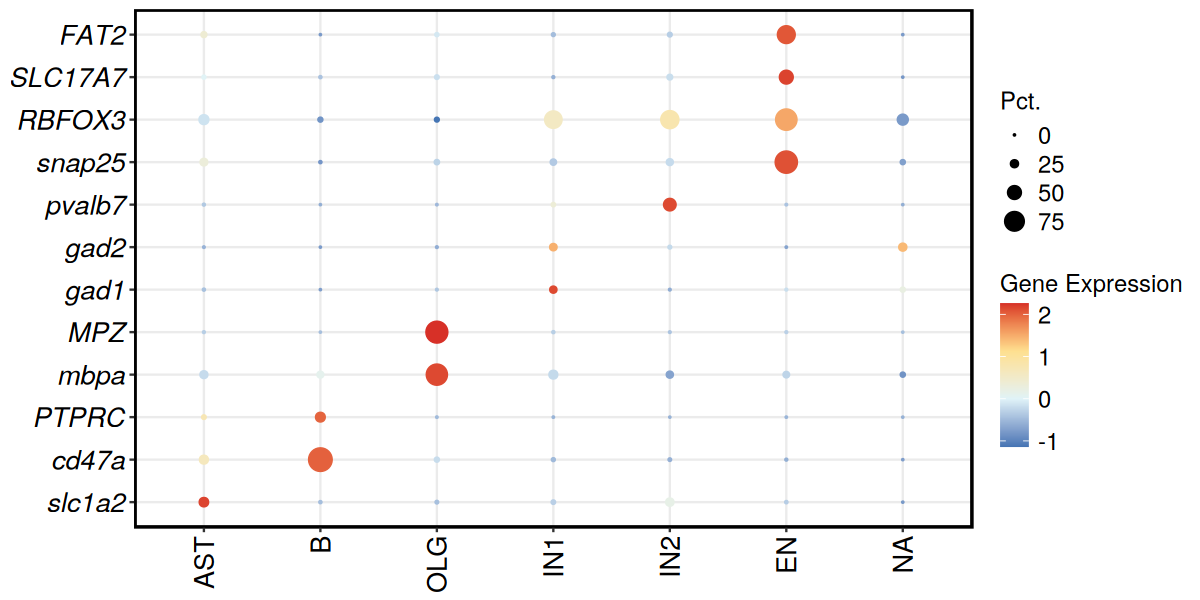

In [84]:
# 绘制不同细胞簇中，marker基因的表达情况
options(repr.plot.width = 10, repr.plot.height = 5)
plot <- DotPlot(sc_lc_order,features = rev(unname(dot_plot_genes1)),group.by = 'celltype') +
    scale_x_discrete(label = rev(names(dot_plot_genes1)) ) +
    coord_flip() +
    theme_bw() +
    theme(#panel.grid = element_blank(),
          legend.title = element_text(size = 14),
          legend.text = element_text(size = 14),
          panel.border = element_rect(color = "black", size = 1),
          axis.text.x = element_text(angle=90,hjust = 1,vjust=0.5,size=16,colour = 'black'),
          axis.text.y = element_text(size=16,colour = 'black', face = "italic")) +
    scale_color_gradientn(values = seq(0,1,0.2),colours = c('#4575B4','#E0F3F8','#FEE090','#D73027'))+
    labs(x=NULL,y=NULL)+guides(size=guide_legend(order=3)) +
    guides(size = guide_legend(title = "Pct."),color = guide_colorbar(title = "Gene Expression"))
plot

In [86]:
# 自定义不同细胞簇对应的颜色
celltype_colors <- c(
  "EN" = "#B8E8E8", 
  "IN1" = "#C8BFF0",   
  "IN2" = "#B8ACEB",  
  "NA" = "#EE82EE", 
  "AST" = "#F8D0A8",  
  "B" = "#C9E4CA",  
  "OLG" = "#92CDF6"
)
length(celltype_colors) 

[1] 7

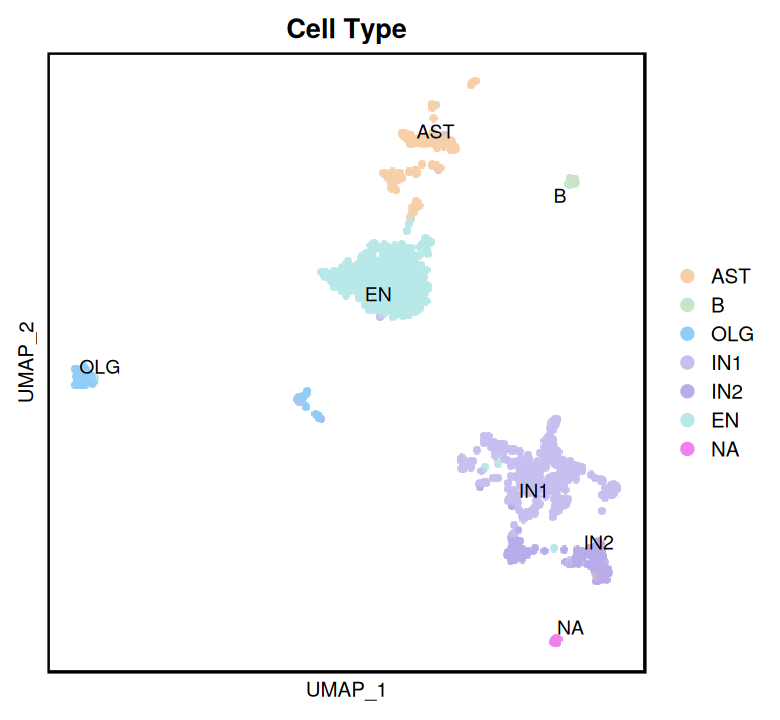

In [92]:
# 绘制细胞亚簇umap聚类图
options(repr.plot.width = 6.5, repr.plot.height = 6)
plot_marker <- DimPlot(object = sc_lc_order, raster = TRUE,label = T,repel = T,
        reduction = "umap.harmony",
        group.by = "celltype",
        cols = celltype_colors,
        pt.size = 4) + 
    theme_bw() +
    theme(
        panel.border = element_rect(color = "black", fill = NA, size = 1), # 设置边框为黑色
        axis.ticks = element_blank(),                                      # 去除刻度线
        panel.grid.major = element_blank(),                                # 主网格线去除
        panel.grid.minor = element_blank(),                                # 次网格线去除
        plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
        legend.title = element_text(size = 14),
        legend.text = element_text(size = 12),
        axis.text = element_blank(),              # 保留坐标轴刻度文字
        axis.title = element_text(color = "black", size = 12)              # 设置坐标轴标题颜色
    ) +
    labs(title = "Cell Type", x = "UMAP_1", y = "UMAP_2")
plot_marker